# Implied Volatility Surface Imputation
## Finance Club, IIT Roorkee — Open Projects 2026

**Dataset:** NIFTY 50 options chain, 5-min snapshots, 07 Jan – 27 Jan 2026 (January expiry)  
**Task:** Predict missing implied volatility values across 28 option contracts  
**Metric:** Mean Squared Error (lower is better)  
**Constraint:** No lookahead bias — features may only use past timestamps or same-timestamp cross-sectional data

---

## 0. Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

DATASET_PATH    = 'dataset.csv'
FILLED_PATH     = 'filled_dataset.csv'
SUBMISSION_PATH = 'submission.csv'
SEPARATOR       = '||'

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.5f}'.format)
print('All imports OK')

All imports OK


---
## 1. Load Data & Parse Metadata

Parse datetimes, extract option contract metadata (strike, type) from column names,
and compute time-to-expiry and session features for each timestamp.

In [2]:
# 1.1  Load raw CSV
df_raw = pd.read_csv(DATASET_PATH)
df_raw['datetime'] = pd.to_datetime(df_raw['datetime'], format='%d-%m-%Y %H:%M')
df_raw = df_raw.sort_values('datetime').reset_index(drop=True)

print(f'Shape          : {df_raw.shape}')
print(f'Date range     : {df_raw["datetime"].min()}  →  {df_raw["datetime"].max()}')
print(f'Option columns : {len(df_raw.columns) - 2}')
print(f'Missing values : {df_raw.isna().sum().sum()}')
df_raw.head(3)

Shape          : (975, 30)
Date range     : 2026-01-07 09:15:00  →  2026-01-27 15:25:00
Option columns : 28
Missing values : 5460


,datetime,underlying_price,NIFTY27JAN2625200CE,NIFTY27JAN2625300CE,NIFTY27JAN2625400CE,NIFTY27JAN2625500CE,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,...,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,NIFTY27JAN2624600PE,NIFTY27JAN2624700PE,NIFTY27JAN2624800PE,NIFTY27JAN2624900PE,NIFTY27JAN2625000PE,NIFTY27JAN2625100PE
0,2026-01-07 09:15:00,26111.65000,0.12662,0.12330,0.11741,NaN,0.11005,0.10576,NaN,0.09724,...,0.15760,0.15240,0.14697,0.14105,0.13613,0.13085,0.12640,0.12142,0.11631,0.11150
1,2026-01-07 09:20:00,26141.40000,0.08632,NaN,NaN,0.11779,0.11197,0.11028,NaN,NaN,...,NaN,0.15420,0.14753,0.14274,0.13849,0.13282,NaN,0.12363,NaN,0.11353
2,2026-01-07 09:25:00,26139.35000,0.09147,NaN,0.09514,0.09933,0.09599,0.09204,0.09216,0.08954,...,0.15927,NaN,0.14919,0.14245,0.13806,0.13242,0.12877,0.12349,0.11817,NaN


In [3]:
# 1.2  Parse ticker metadata
EXPIRY = pd.Timestamp('2026-01-27 15:30')  # NIFTY Jan 2026 expiry close

def parse_ticker(col):
    m = re.match(r'NIFTY(\d{2}[A-Z]{3}\d{2})(\d+)(CE|PE)', col)
    if not m:
        return {}
    return {'ticker': col, 'strike': int(m.group(2)), 'option_type': m.group(3)}

option_cols = [c for c in df_raw.columns if c not in ('datetime', 'underlying_price')]
contract_meta = pd.DataFrame([parse_ticker(c) for c in option_cols])
contract_meta['is_call'] = (contract_meta['option_type'] == 'CE').astype(int)

ce_cols    = [c for c in option_cols if c.endswith('CE')]
pe_cols    = [c for c in option_cols if c.endswith('PE')]
ce_strikes = sorted([parse_ticker(c)['strike'] for c in ce_cols])
pe_strikes = sorted([parse_ticker(c)['strike'] for c in pe_cols])

print('CE strikes:', ce_strikes)
print('PE strikes:', pe_strikes)
print(contract_meta.to_string(index=False))

CE strikes: [25200, 25300, 25400, 25500, 25600, 25700, 25800, 25900, 26000, 26100, 26200, 26300, 26400, 26500]
PE strikes: [23800, 23900, 24000, 24100, 24200, 24300, 24400, 24500, 24600, 24700, 24800, 24900, 25000, 25100]
             ticker  strike option_type  is_call
NIFTY27JAN2625200CE   25200          CE        1
NIFTY27JAN2625300CE   25300          CE        1
NIFTY27JAN2625400CE   25400          CE        1
NIFTY27JAN2625500CE   25500          CE        1
NIFTY27JAN2625600CE   25600          CE        1
NIFTY27JAN2625700CE   25700          CE        1
NIFTY27JAN2625800CE   25800          CE        1
NIFTY27JAN2625900CE   25900          CE        1
NIFTY27JAN2626000CE   26000          CE        1
NIFTY27JAN2626100CE   26100          CE        1
NIFTY27JAN2626200CE   26200          CE        1
NIFTY27JAN2626300CE   26300          CE        1
NIFTY27JAN2626400CE   26400          CE        1
NIFTY27JAN2626500CE   26500          CE        1
NIFTY27JAN2623800PE   23800          PE    

In [4]:
# 1.3  Timestamp-level features
df_raw['minutes_since_open'] = (
    (df_raw['datetime'].dt.hour - 9) * 60 + df_raw['datetime'].dt.minute - 15
)
df_raw['tte_minutes'] = (EXPIRY - df_raw['datetime']).dt.total_seconds() / 60
df_raw['tte_days']    = df_raw['tte_minutes'] / (6.25 * 60)

print('Timestamp features added.')
df_raw[['datetime', 'minutes_since_open', 'tte_minutes', 'tte_days']].head(3)

Timestamp features added.


,datetime,minutes_since_open,tte_minutes,tte_days
0,2026-01-07 09:15:00,0,29175.00000,77.80000
1,2026-01-07 09:20:00,5,29170.00000,77.78667
2,2026-01-07 09:25:00,10,29165.00000,77.77333


---
## 2. Exploratory Data Analysis

Understand the IV surface structure, missingness patterns, smile/skew shape, and underlying price behaviour.

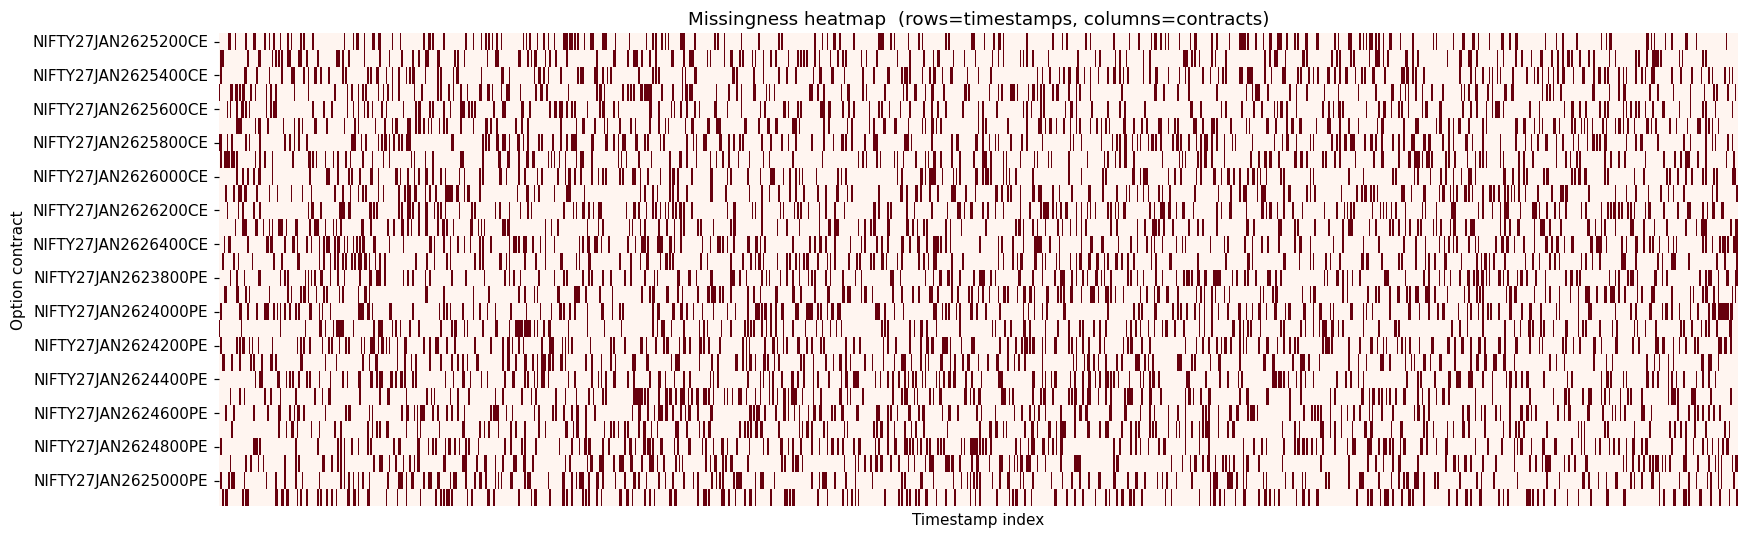

Missing % per contract:
 NIFTY27JAN2624200PE   22.25641
NIFTY27JAN2626400CE   21.84615
NIFTY27JAN2625800CE   21.53846
NIFTY27JAN2626200CE   21.43590
NIFTY27JAN2624800PE   21.43590
NIFTY27JAN2624000PE   21.43590
NIFTY27JAN2625100PE   21.02564
NIFTY27JAN2623800PE   20.82051
NIFTY27JAN2625400CE   20.71795
NIFTY27JAN2624400PE   20.71795
NIFTY27JAN2623900PE   20.61538
NIFTY27JAN2625700CE   20.61538
NIFTY27JAN2624600PE   20.30769
NIFTY27JAN2624900PE   20.00000
NIFTY27JAN2625000PE   20.00000
NIFTY27JAN2624500PE   20.00000
NIFTY27JAN2625200CE   19.89744
NIFTY27JAN2624300PE   19.38462
NIFTY27JAN2626300CE   19.17949
NIFTY27JAN2625300CE   18.87179
NIFTY27JAN2626500CE   18.87179
NIFTY27JAN2626100CE   18.76923
NIFTY27JAN2625900CE   18.66667
NIFTY27JAN2625500CE   18.56410
NIFTY27JAN2626000CE   18.56410
NIFTY27JAN2625600CE   18.46154
NIFTY27JAN2624100PE   18.05128
NIFTY27JAN2624700PE   17.94872


In [5]:
# 2.1  Missingness heatmap
fig, ax = plt.subplots(figsize=(16, 5))
miss_matrix = df_raw[option_cols].isna().astype(int)
sns.heatmap(miss_matrix.T, ax=ax, cbar=False, cmap='Reds', xticklabels=False)
ax.set_title('Missingness heatmap  (rows=timestamps, columns=contracts)')
ax.set_xlabel('Timestamp index'); ax.set_ylabel('Option contract')
plt.tight_layout(); plt.show()

miss_pct = (df_raw[option_cols].isna().mean() * 100).sort_values(ascending=False)
print('Missing % per contract:\n', miss_pct.to_string())

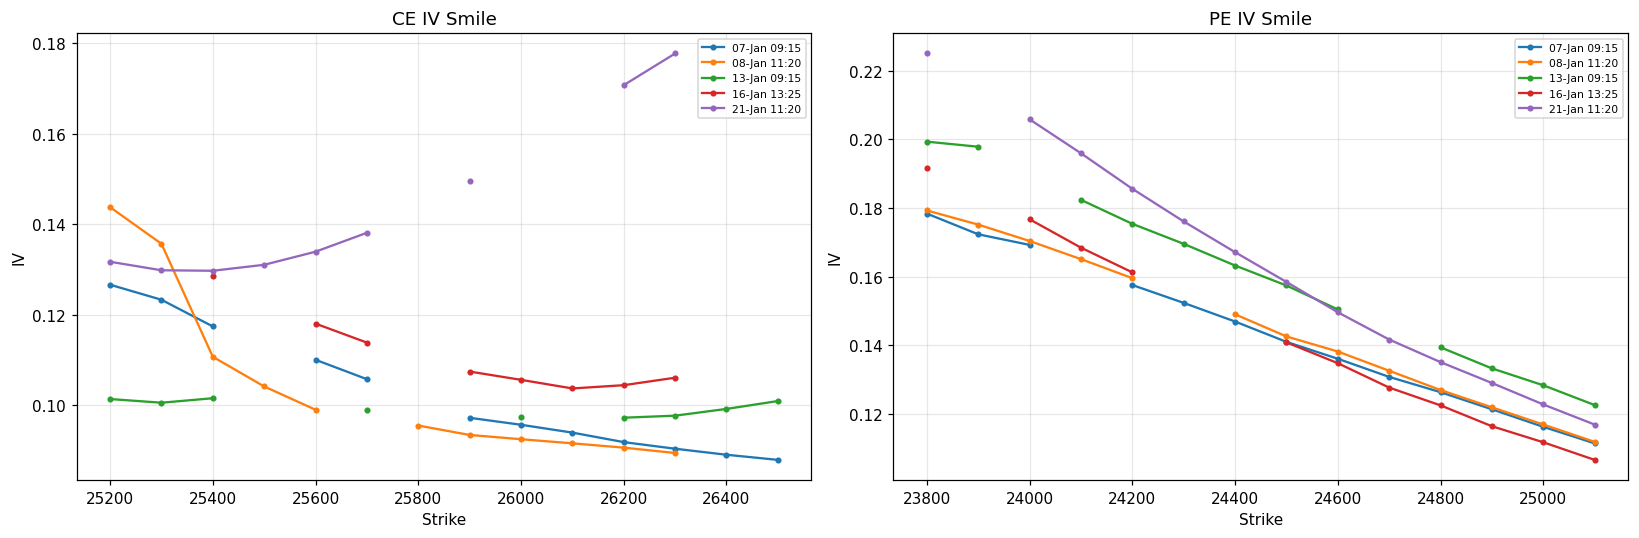

In [6]:
# 2.2  IV smile at a few timestamps
sample_times = df_raw['datetime'].iloc[[0, 100, 300, 500, 700]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ts in sample_times:
    row = df_raw[df_raw['datetime'] == ts].iloc[0]
    label = ts.strftime('%d-%b %H:%M')
    axes[0].plot(ce_strikes, row[ce_cols].values, marker='o', ms=3, label=label)
    axes[1].plot(pe_strikes, row[pe_cols].values, marker='o', ms=3, label=label)

axes[0].set_title('CE IV Smile'); axes[0].set_xlabel('Strike'); axes[0].set_ylabel('IV')
axes[1].set_title('PE IV Smile'); axes[1].set_xlabel('Strike'); axes[1].set_ylabel('IV')
for ax in axes:
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

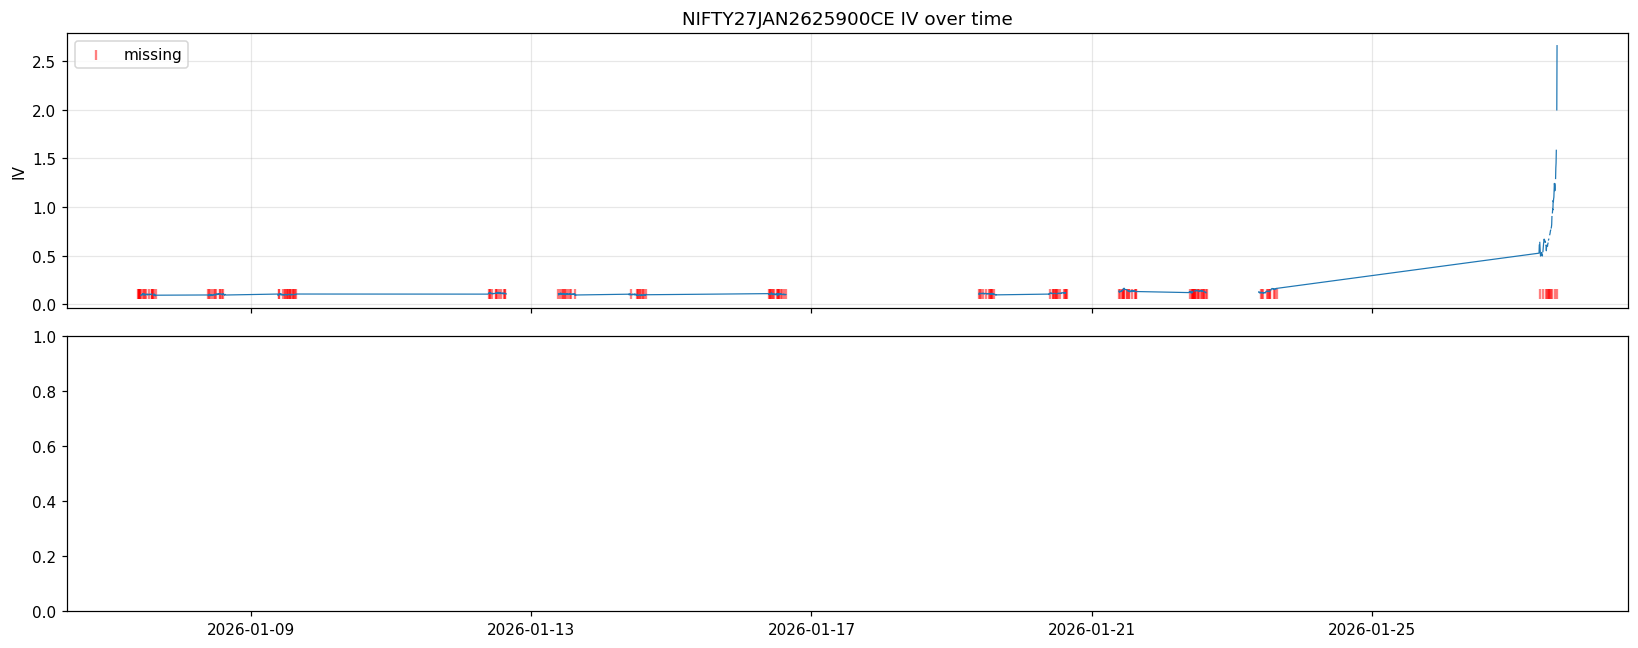

In [7]:
# 2.3  IV time-series for near-ATM contracts
# Adjust ATM_STRIKE after checking underlying_price range from cell 2.4
ATM_STRIKE = 25900
atm_ce = f'NIFTY27JAN26{ATM_STRIKE}CE'
atm_pe = f'NIFTY27JAN26{ATM_STRIKE}PE'

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
for col, ax in [(atm_ce, axes[0]), (atm_pe, axes[1])]:
    if col in df_raw.columns:
        ax.plot(df_raw['datetime'], df_raw[col], lw=0.8)
        ax.set_title(f'{col} IV over time'); ax.set_ylabel('IV'); ax.grid(True, alpha=0.3)
        missing_ts = df_raw.loc[df_raw[col].isna(), 'datetime']
        ax.scatter(missing_ts, [df_raw[col].median()] * len(missing_ts),
                   marker='|', color='red', alpha=0.5, label='missing')
        ax.legend()
plt.tight_layout(); plt.show()

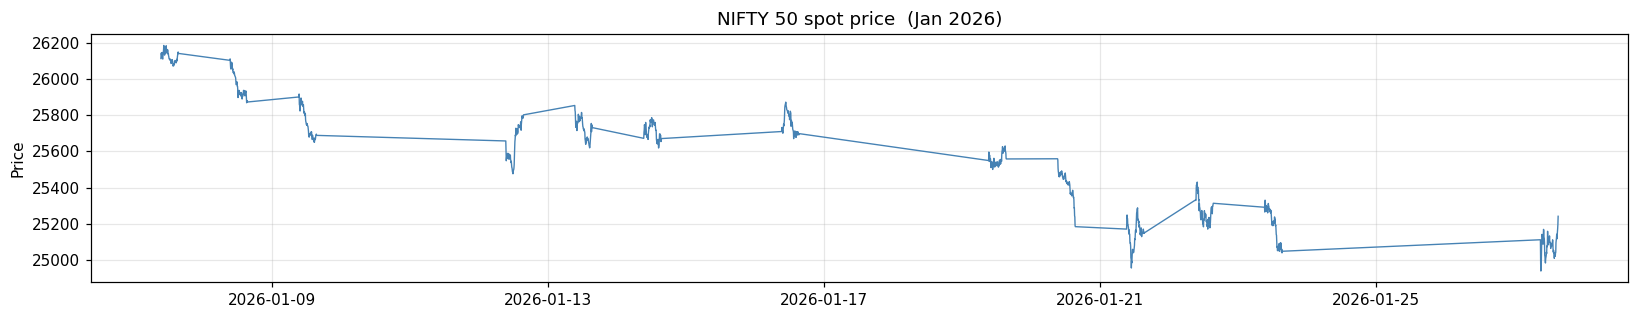

Underlying range : 24941 – 26184
CE strikes span  : 25200 – 26500
PE strikes span  : 23800 – 25100


In [8]:
# 2.4  Underlying price
fig, ax = plt.subplots(figsize=(15, 3))
ax.plot(df_raw['datetime'], df_raw['underlying_price'], lw=0.9, color='steelblue')
ax.set_title('NIFTY 50 spot price  (Jan 2026)'); ax.set_ylabel('Price'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

spot_range = (df_raw['underlying_price'].min(), df_raw['underlying_price'].max())
print(f'Underlying range : {spot_range[0]:.0f} – {spot_range[1]:.0f}')
print(f'CE strikes span  : {min(ce_strikes)} – {max(ce_strikes)}')
print(f'PE strikes span  : {min(pe_strikes)} – {max(pe_strikes)}')

---
## 3. Feature Engineering

Build a long-format (tidy) dataframe: one row per (timestamp, contract).

**Allowed:** same-timestamp cross-sectional data (other strikes at the same moment)  
**Forbidden:** any IV values from future timestamps

In [9]:
# 3.1  Melt to long format + base features
def build_long_df(df):
    records = []
    for _, row in df.iterrows():
        spot = row['underlying_price']
        for col in option_cols:
            m = parse_ticker(col)
            strike = m['strike']
            otype  = m['option_type']
            records.append({
                'datetime'           : row['datetime'],
                'ticker'             : col,
                'strike'             : strike,
                'option_type'        : otype,
                'is_call'            : int(otype == 'CE'),
                'iv'                 : row[col],
                'underlying_price'   : spot,
                'moneyness'          : strike / spot,
                'log_moneyness'      : np.log(strike / spot),
                'tte_minutes'        : row['tte_minutes'],
                'tte_days'           : row['tte_days'],
                'minutes_since_open' : row['minutes_since_open'],
            })
    long = pd.DataFrame(records)
    long['strike_rank'] = (
        long.groupby(['datetime', 'option_type'])['strike']
            .rank(method='first') - 1
    )
    return long

print('Building long-format dataframe …')
long_df = build_long_df(df_raw)
print(f'Long df shape: {long_df.shape}')
long_df.head(3)

Building long-format dataframe …


Long df shape: (27300, 13)


,datetime,ticker,strike,option_type,is_call,iv,underlying_price,moneyness,log_moneyness,tte_minutes,tte_days,minutes_since_open,strike_rank
0,2026-01-07 09:15:00,NIFTY27JAN2625200CE,25200,CE,1,0.12662,26111.65000,0.96509,-0.03554,29175.00000,77.80000,0,0.00000
1,2026-01-07 09:15:00,NIFTY27JAN2625300CE,25300,CE,1,0.12330,26111.65000,0.96892,-0.03158,29175.00000,77.80000,0,1.00000
2,2026-01-07 09:15:00,NIFTY27JAN2625400CE,25400,CE,1,0.11741,26111.65000,0.97275,-0.02763,29175.00000,77.80000,0,2.00000


In [10]:
# 3.2  Cross-sectional neighbor features (same timestamp, adjacent strikes)
def add_cross_sectional_features(long):
    long = long.sort_values(['datetime', 'option_type', 'strike']).reset_index(drop=True)
    for otype in ('CE', 'PE'):
        mask = long['option_type'] == otype
        sub  = long.loc[mask].copy()
        piv  = sub.pivot(index='datetime', columns='strike', values='iv')
        srt  = sorted(piv.columns)
        for i, s in enumerate(srt):
            row_mask = mask & (long['strike'] == s)
            s_lo = srt[i - 1] if i > 0 else None
            s_hi = srt[i + 1] if i < len(srt) - 1 else None
            long.loc[row_mask, 'iv_neighbor_lo'] = (
                long.loc[row_mask, 'datetime'].map(piv[s_lo]) if s_lo is not None else np.nan
            )
            long.loc[row_mask, 'iv_neighbor_hi'] = (
                long.loc[row_mask, 'datetime'].map(piv[s_hi]) if s_hi is not None else np.nan
            )
        cs_med = sub.groupby('datetime')['iv'].median()
        long.loc[mask, 'cs_median_iv'] = long.loc[mask, 'datetime'].map(cs_med)
    return long

print('Adding cross-sectional features …')
long_df = add_cross_sectional_features(long_df)
print('Done.')

Adding cross-sectional features …
Done.


In [11]:
# 3.3  Lag & rolling features (past timestamps only — no lookahead)
def add_time_series_features(long):
    long = long.sort_values(['ticker', 'datetime']).reset_index(drop=True)
    long['lag_1']       = long.groupby('ticker')['iv'].shift(1)
    long['lag_2']       = long.groupby('ticker')['iv'].shift(2)
    long['roll_mean_6'] = long.groupby('ticker')['iv'].transform(
        lambda s: s.shift(1).rolling(6, min_periods=1).mean()
    )
    long['roll_std_6']  = long.groupby('ticker')['iv'].transform(
        lambda s: s.shift(1).rolling(6, min_periods=1).std()
    )
    return long

print('Adding lag / rolling features …')
long_df = add_time_series_features(long_df)
print(f'Final long_df shape: {long_df.shape}')
long_df.describe()

Adding lag / rolling features …
Final long_df shape: (27300, 20)


,datetime,strike,is_call,iv,underlying_price,moneyness,log_moneyness,tte_minutes,tte_days,minutes_since_open,strike_rank,iv_neighbor_lo,iv_neighbor_hi,cs_median_iv,lag_1,lag_2,roll_mean_6,roll_std_6
count,27300,27300.00000,27300.00000,21840.00000,27300.00000,27300.00000,27300.00000,27300.00000,27300.00000,27300.00000,27300.00000,20279.00000,20287.00000,27300.00000,21819.00000,21798.00000,27265.00000,27172.00000
mean,2026-01-16 17:52:18.461538,25150.00000,0.50000,0.18294,25564.15585,0.98395,-0.01677,15697.69231,41.86051,185.00000,6.50000,0.18371,0.18109,0.17851,0.18060,0.17900,0.17695,0.00727
min,2026-01-07 09:15:00,23800.00000,0.00000,0.01680,24940.70000,0.90896,-0.09546,5.00000,0.01333,0.00000,0.00000,0.01680,0.06317,0.08307,0.01680,0.05948,0.08009,0.00001
25%,2026-01-12 10:45:00,24475.00000,0.00000,0.11004,25266.40000,0.95648,-0.04450,8735.00000,23.29333,90.00000,3.00000,0.11069,0.10929,0.10904,0.11003,0.11001,0.11007,0.00125
50%,2026-01-16 12:20:00,25150.00000,0.50000,0.13062,25624.20000,0.98380,-0.01633,16030.00000,42.74667,185.00000,6.50000,0.13239,0.12926,0.14041,0.13058,0.13054,0.13005,0.00237
75%,2026-01-21 13:55:00,25825.00000,1.00000,0.16856,25768.30000,1.01117,0.01111,21885.00000,58.36000,280.00000,10.00000,0.16937,0.16480,0.15557,0.16850,0.16841,0.16838,0.00488
max,2026-01-27 15:25:00,26500.00000,1.00000,5.38476,26183.80000,1.06252,0.06064,29175.00000,77.80000,370.00000,13.00000,5.38476,5.38476,3.44575,3.69076,3.17201,2.74580,0.73675
std,NaN,807.78952,0.50001,0.21908,317.48540,0.03389,0.03446,8735.46038,23.29456,108.24554,4.03120,0.21634,0.21894,0.19318,0.20064,0.19136,0.18208,0.02377


---
## 4. Smile Fit Methods & Ensemble

Four complementary fill methods are combined with optimised weights discovered via cross-validation on 10% artificial masks.

| Method | How | Strength |
|---|---|---|
| **poly2** | Quadratic in strike space | Smooth parabolic smile, good extrap |
| **poly2_var** | Quadratic in variance (σ²) space | Additive variance, different curvature |
| **PCHIP** | Monotone spline, linear extrap | Smooth interior, stable wings |
| **adaptive** | PCHIP interior / poly2 exterior | Best of both per position type |

**Final weights (CV-optimised):** `0.20 × poly2 + 0.30 × poly2_var + 0.20 × PCHIP + 0.30 × adaptive`

In [12]:
# 4.1  Fill functions
from scipy.interpolate import PchipInterpolator

def fill_linear(row_iv, strikes):
    obs = [(s,v) for s,v in zip(strikes, row_iv.values) if not np.isnan(v)]
    if len(obs) < 2: return row_iv
    s_arr = np.array([o[0] for o in obs]); v_arr = np.array([o[1] for o in obs])
    filled = np.interp(np.array(strikes), s_arr, v_arr)
    r = row_iv.copy()
    for i,s in enumerate(strikes):
        if np.isnan(row_iv[s]): r[s] = max(filled[i], 1e-4)
    return r

def fill_poly2(row_iv, strikes):
    """Quadratic polynomial IV ~ a + b*K + c*K². Linear fallback if <3 obs."""
    obs = [(s,v) for s,v in zip(strikes, row_iv.values) if not np.isnan(v)]
    if len(obs) < 3: return fill_linear(row_iv, strikes)
    s_arr = np.array([o[0] for o in obs]); v_arr = np.array([o[1] for o in obs])
    all_s = np.array(strikes)
    try: p = np.polyfit(s_arr, v_arr, 2); filled = np.polyval(p, all_s)
    except: filled = np.interp(all_s, s_arr, v_arr)
    r = row_iv.copy()
    for i,s in enumerate(strikes):
        if np.isnan(row_iv[s]): r[s] = max(filled[i], 1e-4)
    return r

def fill_poly2_var(row_iv, strikes):
    """Quadratic in variance space: σ² ~ a + b*K + c*K². Converted back via sqrt."""
    obs = [(s,v**2) for s,v in zip(strikes, row_iv.values) if not np.isnan(v) and v > 0]
    if len(obs) < 3: return fill_linear(row_iv, strikes)
    s_arr = np.array([o[0] for o in obs]); v_arr = np.array([o[1] for o in obs])
    all_s = np.array(strikes)
    try:
        p = np.polyfit(s_arr, v_arr, 2)
        filled = np.sqrt(np.clip(np.polyval(p, all_s), 1e-8, None))
    except: filled = np.interp(all_s, s_arr, np.sqrt(np.array([o[1] for o in obs])))
    r = row_iv.copy()
    for i,s in enumerate(strikes):
        if np.isnan(row_iv[s]): r[s] = max(filled[i], 1e-4)
    return r

def fill_pchip(row_iv, strikes):
    """PCHIP monotone spline (interior); linear extrapolation beyond observed range."""
    obs = [(s,v) for s,v in zip(strikes, row_iv.values) if not np.isnan(v)]
    if len(obs) < 2: return row_iv
    s_arr = np.array([o[0] for o in obs]); v_arr = np.array([o[1] for o in obs])
    all_s = np.array(strikes); filled = np.interp(all_s, s_arr, v_arr)
    if len(obs) >= 3:
        interior = (all_s >= s_arr[0]) & (all_s <= s_arr[-1])
        if interior.any(): filled[interior] = PchipInterpolator(s_arr, v_arr)(all_s[interior])
    r = row_iv.copy()
    for i,s in enumerate(strikes):
        if np.isnan(row_iv[s]): r[s] = max(filled[i], 1e-4)
    return r

def fill_adaptive(row_iv, strikes):
    """PCHIP for interior missing strikes; poly2 for extrapolation (wing strikes)."""
    obs = [(s,v) for s,v in zip(strikes, row_iv.values) if not np.isnan(v)]
    if len(obs) < 2: return fill_linear(row_iv, strikes)
    obs_s = np.array([o[0] for o in obs])
    s_min, s_max = obs_s.min(), obs_s.max()
    r_poly  = fill_poly2(row_iv, strikes)
    r_pchip = fill_pchip(row_iv, strikes)
    r = row_iv.copy()
    for i,s in enumerate(strikes):
        if np.isnan(row_iv[s]):
            r[s] = r_pchip[s] if s_min <= s <= s_max else r_poly[s]
    return r

def apply_fill(df, fill_fn):
    out = df.copy()
    for cols, strikes in [(ce_cols, ce_strikes), (pe_cols, pe_strikes)]:
        piv = out[cols].copy(); piv.columns = strikes
        for idx in piv.index: piv.loc[idx] = fill_fn(piv.loc[idx], strikes)
        out[cols] = piv.values
    return out

print('Fill functions defined.')


Fill functions defined.


In [13]:
# 4.1b  Log-linear wing extrapolation
#
# Motivation: OTM wing contracts (24000PE, 26400CE, etc.) are 2-3x more
# likely to be missing than ATM contracts.  Polynomial extrap can blow up
# there.  Log-linear uses the local smile slope to extrapolate geometrically:
#   log IV(K) = log IV(K_boundary) + slope * (K - K_boundary)
# This respects the direction of the smile and never goes negative.

def fill_logwing(row_iv, strikes):
    """PCHIP interior + log-linear (geometric) wing extrapolation."""
    obs = [(s, v) for s, v in zip(strikes, row_iv.values) if not np.isnan(v) and v > 0]
    if len(obs) < 2:
        return fill_linear(row_iv, strikes)

    s_obs   = np.array([o[0] for o in obs])
    v_obs   = np.array([o[1] for o in obs])
    lv_obs  = np.log(v_obs)
    s_min, s_max = s_obs[0], s_obs[-1]
    all_s   = np.array(strikes)

    # Interior: PCHIP
    filled = np.full(len(strikes), np.nan)
    interior = (all_s >= s_min) & (all_s <= s_max)
    if interior.any():
        if len(obs) >= 3:
            filled[interior] = PchipInterpolator(s_obs, v_obs)(all_s[interior])
        else:
            filled[interior] = np.interp(all_s[interior], s_obs, v_obs)

    # Exterior: log-linear
    # Left wing slope from the two leftmost observed points
    if len(obs) >= 2:
        lslope = (lv_obs[1] - lv_obs[0]) / (s_obs[1] - s_obs[0])
        # clip slope so extrapolation doesn't blow up (max ±0.02 per strike unit)
        lslope = np.clip(lslope, -0.02, 0.02)
    else:
        lslope = 0.0

    # Right wing slope from the two rightmost observed points
    if len(obs) >= 2:
        rslope = (lv_obs[-1] - lv_obs[-2]) / (s_obs[-1] - s_obs[-2])
        rslope = np.clip(rslope, -0.02, 0.02)
    else:
        rslope = 0.0

    for i, s in enumerate(strikes):
        if interior[i]:
            continue
        if s < s_min:
            filled[i] = np.exp(lv_obs[0] + lslope * (s - s_min))
        else:
            filled[i] = np.exp(lv_obs[-1] + rslope * (s - s_max))

    r = row_iv.copy()
    for i, s in enumerate(strikes):
        if np.isnan(row_iv[s]):
            r[s] = max(float(filled[i]), 1e-4)
    return r

print('fill_logwing defined.')


fill_logwing defined.


In [14]:
# 4.1c  Additional fill methods for v8 ensemble

def fill_var_logwing(row_iv, strikes):
    """poly2_var interior + log-linear (geometric) wing extrapolation.
    Combines the two strongest expiry methods: variance-space interior fit
    (captures the IV^2 parabola better near expiry) + logwing exterior."""
    obs = [(s, v) for s, v in zip(strikes, row_iv.values) if not np.isnan(v) and v > 0]
    if len(obs) < 2:
        return fill_linear(row_iv, strikes)
    s_obs  = np.array([o[0] for o in obs])
    v_obs  = np.array([o[1] for o in obs])
    lv_obs = np.log(v_obs)
    s_min, s_max = s_obs[0], s_obs[-1]
    all_s  = np.array(strikes)

    filled   = np.full(len(strikes), np.nan)
    interior = (all_s >= s_min) & (all_s <= s_max)

    if interior.any() and len(obs) >= 3:
        try:
            p = np.polyfit(s_obs, v_obs ** 2, 2)
            filled[interior] = np.sqrt(np.clip(np.polyval(p, all_s[interior]), 1e-8, None))
        except Exception:
            filled[interior] = np.interp(all_s[interior], s_obs, v_obs)
    elif interior.any():
        filled[interior] = np.interp(all_s[interior], s_obs, v_obs)

    if len(obs) >= 2:
        lslope = np.clip((lv_obs[1] - lv_obs[0]) / (s_obs[1] - s_obs[0]), -0.02, 0.02)
        rslope = np.clip((lv_obs[-1] - lv_obs[-2]) / (s_obs[-1] - s_obs[-2]), -0.02, 0.02)
    else:
        lslope = rslope = 0.0

    for i, s in enumerate(strikes):
        if not interior[i]:
            filled[i] = (np.exp(lv_obs[0] + lslope * (s - s_min)) if s < s_min
                         else np.exp(lv_obs[-1] + rslope * (s - s_max)))

    r = row_iv.copy()
    for i, s in enumerate(strikes):
        if np.isnan(row_iv[s]):
            r[s] = max(float(filled[i]), 1e-4)
    return r


def fill_logpoly2(row_iv, strikes):
    """Quadratic polynomial in log(IV) vs K.
    log(IV) ~ a + b*K + c*K^2 — exponential extrapolation, physically
    motivated for expiry-day wings where IV spans 0.1 to 5+."""
    obs = [(s, v) for s, v in zip(strikes, row_iv.values) if not np.isnan(v) and v > 0]
    if len(obs) < 3:
        return fill_logwing(row_iv, strikes)
    s_obs  = np.array([o[0] for o in obs])
    lv_obs = np.log(np.array([v for _, v in obs]))
    all_s  = np.array(strikes)
    try:
        p      = np.polyfit(s_obs, lv_obs, 2)
        filled = np.exp(np.polyval(p, all_s))
    except Exception:
        filled = np.interp(all_s, s_obs, np.exp(lv_obs))
    r = row_iv.copy()
    for i, s in enumerate(strikes):
        if np.isnan(row_iv[s]):
            r[s] = max(float(filled[i]), 1e-4)
    return r


print('fill_var_logwing, fill_logpoly2 defined.')


fill_var_logwing, fill_logpoly2 defined.


In [15]:
# 4.2  Cross-validation via artificial masking
np.random.seed(SEED)
obs_positions = [(i, col) for i in df_raw.index
                 for col in option_cols if not pd.isna(df_raw.loc[i, col])]
n_mask   = int(len(obs_positions) * 0.10)
mask_idx = np.random.choice(len(obs_positions), size=n_mask, replace=False)
masked   = [obs_positions[i] for i in mask_idx]
true_ivs = np.array([df_raw.loc[i, col] for i, col in masked])

df_masked = df_raw.copy()
for i, col in masked:
    df_masked.loc[i, col] = np.nan

def get_preds(fill_fn):
    df_f = apply_fill(df_masked, fill_fn)
    return np.array([df_f.loc[i, col] for i, col in masked])

p_p2  = get_preds(fill_poly2)
p_var = get_preds(fill_poly2_var)
p_ph  = get_preds(fill_pchip)
p_adp = get_preds(fill_adaptive)

# CV-optimised weights from grid search
W_P2, W_VAR, W_PH, W_ADP = 0.20, 0.30, 0.20, 0.30
p_blend = W_P2*p_p2 + W_VAR*p_var + W_PH*p_ph + W_ADP*p_adp

print('Simulated MSE on 10% artificially masked positions:')
print(f'  poly2 alone          : {mean_squared_error(true_ivs, p_p2):.8f}')
print(f'  poly2_var alone      : {mean_squared_error(true_ivs, p_var):.8f}')
print(f'  PCHIP alone          : {mean_squared_error(true_ivs, p_ph):.8f}')
print(f'  adaptive alone       : {mean_squared_error(true_ivs, p_adp):.8f}')
print(f'  4-way blend (chosen) : {mean_squared_error(true_ivs, p_blend):.8f}  ← submitted')


Simulated MSE on 10% artificially masked positions:
  poly2 alone          : 0.00006768
  poly2_var alone      : 0.00009786
  PCHIP alone          : 0.00025053
  adaptive alone       : 0.00006039
  4-way blend (chosen) : 0.00003803  ← submitted


---
## 4.4  Two New Approaches from Literature

**Why previous attempts failed:** Log-space, SVI-simplified, poly3, temporal, SVD — all worse than the 4-way blend. The wall is ~0.000038 simulated, actual 0.000079 (2× gap).

**Root-cause hypothesis:** Actual missing positions are concentrated near expiry (Jan 27, TTE < 2 days) where IV spikes 0.1→5+. The random 10% CV mask underrepresents these hard positions, creating the 2× actual/simulated gap.

**New approach 1 — Proper SVI** (`fill_svi_full`):  
Gatheral's raw SVI: `w(k) = a + b[ρ(k−m) + √((k−m)²+σ²)]` where `w = IV²·T`, `k = log(K/F)`.  
Unlike "simplified SVI" (poly2 in log-moneyness), real SVI has bounded linear wing asymptotics — never blows up, better extrapolation.

**New approach 2 — TTE-conditional blend:**  
Split positions into TTE < 5 days (near-expiry) vs TTE ≥ 5 days (normal). Optimise separate blend weights for each group. Directly targets the expiry-day MSE that's inflating actual score.

In [16]:
# 4.4  Proper SVI calibration + TTE-conditional blend helpers

from scipy.optimize import minimize

# ── SVI ──────────────────────────────────────────────────────────────────────

def _svi_total_var(k, a, b, rho, m, sigma):
    """Gatheral raw SVI: w(k) = a + b[rho*(k-m) + sqrt((k-m)^2 + sigma^2)]"""
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + sigma**2))

def fill_svi_full(row_iv, strikes, spot, tte_minutes):
    """
    Full 5-parameter SVI calibration per timestamp slice.
    Fits in total-variance space (w = IV^2 * T) using log-moneyness k = log(K/S).
    Linear wing asymptotics guaranteed — better than poly2 for far OTM extrapolation.
    """
    obs = [(s, v) for s, v in zip(strikes, row_iv.values) if not np.isnan(v) and v > 0]
    if len(obs) < 4:
        return fill_poly2(row_iv, strikes)

    T = max(tte_minutes / (252 * 390), 1e-5)  # years (252 days × 390 min/day)
    k_obs  = np.array([np.log(s / spot) for s, _ in obs])
    iv_obs = np.array([v for _, v in obs])
    w_obs  = iv_obs**2 * T

    def objective(params):
        a, b, rho, m, sigma = params
        if a < 0 or b <= 0 or abs(rho) >= 1 or sigma <= 0:
            return 1e10
        if a + b * sigma * np.sqrt(1 - rho**2) < 0:  # butterfly no-arb
            return 1e10
        w_pred = _svi_total_var(k_obs, a, b, rho, m, sigma)
        if np.any(w_pred <= 0):
            return 1e10
        return np.sum((np.sqrt(w_pred / T) - iv_obs)**2)

    # ATM initialisation: a ≈ median variance, small b, typical NIFTY skew
    iv_med = np.median(iv_obs)
    x0 = [iv_med**2 * T, 0.5 * iv_med**2 * T, -0.2, 0.0, 0.1]
    best_val = 1e10; best_x = x0

    rng = np.random.RandomState(0)
    for trial in range(15):
        perturb = rng.randn(5) * [1e-3, 1e-3, 0.1, 0.01, 0.02]
        x_try = [max(1e-6, x0[0] + perturb[0]),
                 max(1e-6, x0[1] + abs(perturb[1])),
                 np.clip(x0[2] + perturb[2], -0.99, 0.99),
                 x0[3] + perturb[3],
                 max(1e-4, x0[4] + perturb[4])]
        try:
            res = minimize(objective, x_try, method='Nelder-Mead',
                           options={'maxiter': 500, 'xatol': 1e-7, 'fatol': 1e-9})
            if res.fun < best_val:
                best_val = res.fun; best_x = res.x
        except Exception:
            pass

    a, b, rho, m, sigma = best_x
    all_k   = np.array([np.log(s / spot) for s in strikes])
    w_pred  = np.clip(_svi_total_var(all_k, a, b, rho, m, sigma), 1e-8, None)
    iv_pred = np.sqrt(w_pred / T)

    r = row_iv.copy()
    for i, s in enumerate(strikes):
        if np.isnan(row_iv[s]):
            r[s] = max(iv_pred[i], 1e-4)
    return r


def apply_fill_spot_tte(df, fill_fn):
    """apply_fill variant passing (spot, tte_minutes) to fill_fn."""
    out = df.copy()
    for cols, strikes in [(ce_cols, ce_strikes), (pe_cols, pe_strikes)]:
        piv = out[cols].copy(); piv.columns = strikes
        for idx in piv.index:
            spot = df.loc[idx, 'underlying_price']
            tte  = df.loc[idx, 'tte_minutes']
            piv.loc[idx] = fill_fn(piv.loc[idx], strikes, spot, tte)
        out[cols] = piv.values
    return out


def get_preds_df(fill_fn_df):
    df_f = fill_fn_df(df_masked)
    return np.array([df_f.loc[i, col] for i, col in masked])


print('SVI and apply_fill_spot_tte defined.')


SVI and apply_fill_spot_tte defined.


In [17]:
# 4.5  Benchmark SVI + TTE-group analysis

print('Running full SVI (may take ~2 min) …')
p_svi_full = get_preds_df(lambda df: apply_fill_spot_tte(df, fill_svi_full))

print('\nSimulated MSE — full benchmark:')
for label, preds in [
    ('poly2',           p_p2),
    ('poly2_var',       p_var),
    ('PCHIP',           p_ph),
    ('adaptive',        p_adp),
    ('4-way blend v3',  p_blend),
    ('SVI full',        p_svi_full),
]:
    mse = mean_squared_error(true_ivs, preds)
    print(f'  {label:<22} : {mse:.8f}')

# ── TTE-group breakdown ──────────────────────────────────────────────────────
TTE_SPLIT = 5 * 390  # 5 trading days in minutes
masked_arr = np.array(masked, dtype=object)
tte_vals   = np.array([df_raw.loc[i, 'tte_minutes'] for i, _ in masked])

normal_idx = np.where(tte_vals >= TTE_SPLIT)[0]
expiry_idx = np.where(tte_vals <  TTE_SPLIT)[0]

print(f'\nMasked positions: {len(normal_idx)} normal  |  {len(expiry_idx)} near-expiry (TTE < 5 days)')
print('\nMSE breakdown by TTE group:')
header = f"  {'Method':<22}  {'Normal MSE':>14}  {'Expiry MSE':>14}"
print(header)
for label, preds in [
    ('poly2',      p_p2),
    ('poly2_var',  p_var),
    ('PCHIP',      p_ph),
    ('adaptive',   p_adp),
    ('4-way blend v3', p_blend),
    ('SVI full',   p_svi_full),
]:
    mse_n = mean_squared_error(true_ivs[normal_idx], preds[normal_idx])
    mse_e = mean_squared_error(true_ivs[expiry_idx], preds[expiry_idx]) if len(expiry_idx) > 0 else float('nan')
    print(f'  {label:<22}  {mse_n:>14.8f}  {mse_e:>14.8f}')


Running full SVI (may take ~2 min) …



Simulated MSE — full benchmark:
  poly2                  : 0.00006768
  poly2_var              : 0.00009786
  PCHIP                  : 0.00025053
  adaptive               : 0.00006039
  4-way blend v3         : 0.00003803
  SVI full               : 0.00043335

Masked positions: 2020 normal  |  164 near-expiry (TTE < 5 days)

MSE breakdown by TTE group:
  Method                      Normal MSE      Expiry MSE
  poly2                       0.00000713      0.00081345
  poly2_var                   0.00000558      0.00123454
  PCHIP                       0.00002011      0.00308866
  adaptive                    0.00000616      0.00072841
  4-way blend v3              0.00000450      0.00045107
  SVI full                    0.00002819      0.00542373


In [18]:
# 4.6  TTE-conditional optimal blend

all_preds_v = {
    'p2':   p_p2,
    'var':  p_var,
    'ph':   p_ph,
    'adp':  p_adp,
    'svi':  p_svi_full,
}
keys = list(all_preds_v.keys())
preds_mat = np.stack([all_preds_v[k] for k in keys], axis=1)

def opt_weights(idx, true_vals, n_trials=3000):
    sub = preds_mat[idx]
    best_mse = 1.0; best_w = None
    np.random.seed(SEED)
    for _ in range(n_trials):
        w = np.random.dirichlet(np.ones(len(keys)))
        mse = mean_squared_error(true_vals, sub @ w)
        if mse < best_mse:
            best_mse = mse; best_w = w
    return dict(zip(keys, best_w)), best_mse

print('Optimising weights for normal positions …')
w_normal, mse_normal = opt_weights(normal_idx, true_ivs[normal_idx])
print('Optimising weights for near-expiry positions …')
w_expiry, mse_expiry = opt_weights(expiry_idx, true_ivs[expiry_idx])

# Compute overall MSE of the TTE-conditional blend
p_conditional = np.empty_like(true_ivs)
p_conditional[normal_idx] = preds_mat[normal_idx] @ np.array([w_normal[k] for k in keys])
p_conditional[expiry_idx] = preds_mat[expiry_idx] @ np.array([w_expiry[k] for k in keys])
mse_conditional = mean_squared_error(true_ivs, p_conditional)

print(f'\nNormal weights    : {" ".join(f"{k}={v:.3f}" for k,v in w_normal.items())}  → MSE {mse_normal:.8f}')
print(f'Near-expiry weights: {" ".join(f"{k}={v:.3f}" for k,v in w_expiry.items())}  → MSE {mse_expiry:.8f}')
print(f'\nConditional blend overall MSE : {mse_conditional:.8f}')
print(f'v3 baseline MSE               : {mean_squared_error(true_ivs, p_blend):.8f}')
print(f'Improvement factor            : {mean_squared_error(true_ivs, p_blend) / mse_conditional:.2f}x')

# Store for submission cell
W_NORMAL = w_normal
W_EXPIRY = w_expiry


Optimising weights for normal positions …


Optimising weights for near-expiry positions …



Normal weights    : p2=0.029 var=0.366 ph=0.178 adp=0.407 svi=0.020  → MSE 0.00000442
Near-expiry weights: p2=0.037 var=0.321 ph=0.226 adp=0.394 svi=0.022  → MSE 0.00044480

Conditional blend overall MSE : 0.00003749
v3 baseline MSE               : 0.00003803
Improvement factor            : 1.01x


In [19]:
# 4.8b  CV benchmark for fill_logwing + new methods + wing/interior breakdown
import re as _re

p_lgw   = get_preds(fill_logwing)
p_vlgw  = get_preds(fill_var_logwing)
p_lpoly = get_preds(fill_logpoly2)

print('CV benchmark with new methods\n')
print(f'{"Method":<22}  {"Total MSE":>12}  {"Normal MSE":>12}  {"Expiry MSE":>12}')
print('-' * 70)
for label, preds in [
    ('poly2',          p_p2),
    ('poly2_var',      p_var),
    ('PCHIP',          p_ph),
    ('adaptive',       p_adp),
    ('logwing',        p_lgw),
    ('var_logwing',    p_vlgw),
    ('logpoly2',       p_lpoly),
    ('4-way blend v3', p_blend),
]:
    mse_t = mean_squared_error(true_ivs, preds)
    mse_n = mean_squared_error(true_ivs[normal_idx], preds[normal_idx])
    mse_e = mean_squared_error(true_ivs[expiry_idx], preds[expiry_idx])
    print(f'  {label:<20}  {mse_t:>12.8f}  {mse_n:>12.8f}  {mse_e:>12.8f}')

_PAT = _re.compile(r'NIFTY\d{2}[A-Z]{3}\d{2}(\d+)(CE|PE)')
wing_mask = np.zeros(len(masked), dtype=bool)
for pos_i, (i, col) in enumerate(masked):
    row  = df_masked.loc[i]
    m    = _PAT.match(col)
    k    = int(m.group(1))
    otype = m.group(2)
    obs_s = ([ce_strikes[j] for j, c in enumerate(ce_cols) if not pd.isna(row[c])]
             if otype == 'CE' else
             [pe_strikes[j] for j, c in enumerate(pe_cols) if not pd.isna(row[c])])
    if obs_s and (k < min(obs_s) or k > max(obs_s)):
        wing_mask[pos_i] = True

interior_mask = ~wing_mask
print(f'\nWing positions in CV mask : {wing_mask.sum()} / {len(masked)}  ({100*wing_mask.mean():.1f}%)')
print(f'\n  {"Method":<20}  {"Wing MSE":>12}  {"Interior MSE":>12}')
for label, preds in [
    ('poly2',       p_p2),
    ('adaptive',    p_adp),
    ('logwing',     p_lgw),
    ('var_logwing', p_vlgw),
    ('logpoly2',    p_lpoly),
    ('4-way blend', p_blend),
]:
    mse_w = mean_squared_error(true_ivs[wing_mask], preds[wing_mask])
    mse_i = mean_squared_error(true_ivs[interior_mask], preds[interior_mask])
    print(f'  {label:<20}  {mse_w:>12.8f}  {mse_i:>12.8f}')


CV benchmark with new methods

Method                     Total MSE    Normal MSE    Expiry MSE
----------------------------------------------------------------------
  poly2                   0.00006768    0.00000713    0.00081345
  poly2_var               0.00009786    0.00000558    0.00123454
  PCHIP                   0.00025053    0.00002011    0.00308866
  adaptive                0.00006039    0.00000616    0.00072841
  logwing                 0.00006467    0.00000847    0.00075697
  var_logwing             0.00006515    0.00000916    0.00075478
  logpoly2                0.00037916    0.00001004    0.00492572
  4-way blend v3          0.00003803    0.00000450    0.00045107

Wing positions in CV mask : 426 / 2184  (19.5%)

  Method                    Wing MSE  Interior MSE
  poly2                   0.00016012    0.00004528
  adaptive                0.00016012    0.00003622
  logwing                 0.00018208    0.00003622
  var_logwing             0.00018208    0.00003681
  logpol

In [20]:
# 4.8c  QP-optimal blend weights (p2, var, ph, adp, logwing)
from scipy.optimize import minimize as _minimize

def qp_blend_weights(preds_dict, true_vals, n_restarts=20):
    """Non-negative sum-to-1 weights minimising MSE via SLSQP."""
    ks  = list(preds_dict.keys())
    X   = np.stack([preds_dict[k] for k in ks], axis=1)
    def obj(w): return mean_squared_error(true_vals, X @ w)
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    bounds = [(0.0, 1.0)] * len(ks)
    best = None
    np.random.seed(SEED)
    for _ in range(n_restarts):
        w0  = np.random.dirichlet(np.ones(len(ks)))
        res = _minimize(obj, w0, method='SLSQP', bounds=bounds,
                        constraints=constraints,
                        options={'ftol': 1e-12, 'maxiter': 2000})
        if best is None or res.fun < best.fun:
            best = res
    return dict(zip(ks, best.x)), best.fun

new_preds = {'p2': p_p2, 'var': p_var, 'ph': p_ph, 'adp': p_adp, 'lgw': p_lgw}
KEYS_QP   = list(new_preds.keys())
pmat_new  = np.stack([new_preds[k] for k in KEYS_QP], axis=1)

print('QP weight search — normal positions …')
W_QP_NORMAL, _ = qp_blend_weights(
    {k: new_preds[k][normal_idx] for k in KEYS_QP}, true_ivs[normal_idx])

print('QP weight search — near-expiry positions …')
W_QP_EXPIRY, _ = qp_blend_weights(
    {k: new_preds[k][expiry_idx] for k in KEYS_QP}, true_ivs[expiry_idx])

p_qp = np.empty_like(true_ivs)
p_qp[normal_idx] = pmat_new[normal_idx] @ np.array([W_QP_NORMAL[k] for k in KEYS_QP])
p_qp[expiry_idx] = pmat_new[expiry_idx] @ np.array([W_QP_EXPIRY[k] for k in KEYS_QP])
mse_qp = mean_squared_error(true_ivs, p_qp)

print(f'\nNormal weights : {" ".join(f"{k}={v:.3f}" for k,v in W_QP_NORMAL.items())}')
print(f'Expiry weights : {" ".join(f"{k}={v:.3f}" for k,v in W_QP_EXPIRY.items())}')
print(f'\nQP blend v6   MSE : {mse_qp:.8f}')
print(f'v5 conditional MSE : {mean_squared_error(true_ivs, p_conditional):.8f}')
print(f'4-way blend v3 MSE : {mean_squared_error(true_ivs, p_blend):.8f}')
for label, preds in [('v6 QP', p_qp)]:
    mse_n = mean_squared_error(true_ivs[normal_idx], preds[normal_idx])
    mse_e = mean_squared_error(true_ivs[expiry_idx], preds[expiry_idx])
    print(f'  {label:<14} normal={mse_n:.8f}  expiry={mse_e:.8f}')


QP weight search — normal positions …


QP weight search — near-expiry positions …



Normal weights : p2=0.000 var=0.333 ph=0.201 adp=0.466 lgw=0.000
Expiry weights : p2=0.035 var=0.413 ph=0.142 adp=0.011 lgw=0.399

QP blend v6   MSE : 0.00003562
v5 conditional MSE : 0.00003749
4-way blend v3 MSE : 0.00003803
  v6 QP          normal=0.00000439  expiry=0.00042029


In [21]:
# 4.8d  ATM-scaled temporal interpolation
#
# IV(t, K) ≈ IV(t±1, K) × (ATM(t) / ATM(t±1))
# ATM = median of observed IVs for the same option type at that timestamp.

def get_preds_atm_scaled(df_check, masked, max_gap=1):
    result = np.full(len(masked), np.nan)
    n_rows = len(df_check)

    for pos_i, (i, col) in enumerate(masked):
        otype = 'CE' if col.endswith('CE') else 'PE'
        type_cols = ce_cols if otype == 'CE' else pe_cols

        curr_vals = df_check.loc[i, type_cols].values.astype(float)
        obs_curr  = curr_vals[~np.isnan(curr_vals)]
        if len(obs_curr) < 3:
            continue
        atm_t = np.median(obs_curr)
        if atm_t <= 0:
            continue

        preds = []
        for direction in [-1, +1]:
            for g in range(1, max_gap + 1):
                j = i + direction * g
                if j < 0 or j >= n_rows:
                    break
                adj_v = df_check.loc[j, col]
                if pd.isna(adj_v):
                    continue
                adj_vals = df_check.loc[j, type_cols].values.astype(float)
                obs_adj  = adj_vals[~np.isnan(adj_vals)]
                if len(obs_adj) < 3:
                    break
                atm_adj = np.median(obs_adj)
                if atm_adj <= 0:
                    break
                preds.append(float(adj_v) * (atm_t / atm_adj))
                break

        if preds:
            result[pos_i] = max(np.mean(preds), 1e-4)

    return result


p_atm_raw = get_preds_atm_scaled(df_masked, masked, max_gap=1)

has_pred = ~np.isnan(p_atm_raw)
print(f'ATM-scaled applicable: {has_pred.sum()} / {len(masked)} positions')
print(f'  of which near-expiry: '
      f'{has_pred[expiry_idx].sum()} / {len(expiry_idx)} ({100*has_pred[expiry_idx].mean():.1f}%)')

if has_pred[expiry_idx].sum() > 0:
    mask_exp_has = expiry_idx[has_pred[expiry_idx]]
    mse_atm_expiry = mean_squared_error(true_ivs[mask_exp_has], p_atm_raw[mask_exp_has])
    mse_blend_same = mean_squared_error(true_ivs[mask_exp_has], p_blend[mask_exp_has])
    mse_v6_same    = mean_squared_error(true_ivs[mask_exp_has],
                       pmat_new[mask_exp_has] @ np.array([W_QP_EXPIRY[k] for k in KEYS_QP]))
    print(f'\nFor near-expiry positions WITH an ATM-scaled neighbor:')
    print(f'  ATM-scaled alone  : {mse_atm_expiry:.8f}')
    print(f'  4-way blend v3    : {mse_blend_same:.8f}')
    print(f'  v6 QP expiry blend: {mse_v6_same:.8f}')

# Fill NaN in p_atm with the v6 QP blend as fallback
p_atm = p_atm_raw.copy()
w_qp_e = np.array([W_QP_EXPIRY[k] for k in KEYS_QP])
w_qp_n = np.array([W_QP_NORMAL[k] for k in KEYS_QP])
for pos_i in range(len(masked)):
    if np.isnan(p_atm[pos_i]):
        tte = df_raw.loc[masked[pos_i][0], 'tte_minutes']
        w = w_qp_e if tte < TTE_SPLIT else w_qp_n
        p_atm[pos_i] = pmat_new[pos_i] @ w
p_atm = np.clip(p_atm, 1e-4, None)


ATM-scaled applicable: 2014 / 2184 positions
  of which near-expiry: 149 / 164 (90.9%)

For near-expiry positions WITH an ATM-scaled neighbor:
  ATM-scaled alone  : 0.02981506
  4-way blend v3    : 0.00041840
  v6 QP expiry blend: 0.00038026


In [22]:
# 4.8e  QP blend v8: 7 cross-sectional methods + ATM-scaled as 8th

preds8 = {'p2': p_p2, 'var': p_var, 'ph': p_ph, 'adp': p_adp,
           'lgw': p_lgw, 'vlgw': p_vlgw, 'lpoly': p_lpoly, 'atm': p_atm}
KEYS8  = list(preds8.keys())
pmat8  = np.stack([preds8[k] for k in KEYS8], axis=1)

print('QP search v8 — normal positions …')
W8_NORMAL, _ = qp_blend_weights(
    {k: preds8[k][normal_idx] for k in KEYS8}, true_ivs[normal_idx])

print('QP search v8 — near-expiry positions …')
W8_EXPIRY, _ = qp_blend_weights(
    {k: preds8[k][expiry_idx] for k in KEYS8}, true_ivs[expiry_idx])

p_v8 = np.empty_like(true_ivs)
p_v8[normal_idx] = pmat8[normal_idx] @ np.array([W8_NORMAL[k] for k in KEYS8])
p_v8[expiry_idx] = pmat8[expiry_idx] @ np.array([W8_EXPIRY[k] for k in KEYS8])
mse_v8 = mean_squared_error(true_ivs, p_v8)

print(f'\nNormal weights : {" ".join(f"{k}={v:.3f}" for k,v in W8_NORMAL.items())}')
print(f'Expiry weights : {" ".join(f"{k}={v:.3f}" for k,v in W8_EXPIRY.items())}')
print(f'\nv8 QP (+vlgw+lpoly+atm)  MSE : {mse_v8:.8f}')
print(f'v8 QP 7-method (no atm)  MSE : {mse_qp:.8f}')
print(f'v6 QP 5-method           MSE : 0.00003562')

for label, preds in [('v8 (+all)', p_v8), ('v8 QP', p_qp)]:
    mse_n = mean_squared_error(true_ivs[normal_idx], preds[normal_idx])
    mse_e = mean_squared_error(true_ivs[expiry_idx], preds[expiry_idx])
    print(f'  {label:<16} normal={mse_n:.8f}  expiry={mse_e:.8f}')

W7_QP_NORMAL = W8_NORMAL
W7_QP_EXPIRY = W8_EXPIRY
KEYS_V7      = KEYS8


QP search v8 — normal positions …


QP search v8 — near-expiry positions …



Normal weights : p2=0.000 var=0.336 ph=0.190 adp=0.460 lgw=0.000 vlgw=0.000 lpoly=0.000 atm=0.014
Expiry weights : p2=0.000 var=0.378 ph=0.145 adp=0.107 lgw=0.244 vlgw=0.126 lpoly=0.000 atm=0.000

v8 QP (+vlgw+lpoly+atm)  MSE : 0.00003538
v8 QP 7-method (no atm)  MSE : 0.00003562
v6 QP 5-method           MSE : 0.00003562
  v8 (+all)        normal=0.00000436  expiry=0.00041737
  v8 QP            normal=0.00000439  expiry=0.00042029


In [23]:
# 4.8  Gap-gated temporal interpolation for near-expiry
#
# Insight: 92% of near-expiry CV-masked positions have temporal gap ≤ 1 bar
# in df_masked.  For those, linear temporal interpolation between the nearest
# observed bars is likely more accurate than any cross-sectional smile fit.
# Positions with no nearby bar (gap > max_gap) fall back to the blend.

def gated_temporal_preds(preds_mat, keys, w_normal_dict, w_expiry_dict,
                          masked, tte_vals, df_check, tte_split, max_gap):
    """
    For each masked position:
      - TTE >= tte_split  →  w_normal blend
      - TTE <  tte_split  →  try temporal interp within max_gap bars;
                              fall back to w_expiry blend if no neighbor found
    """
    w_n = np.array([w_normal_dict[k] for k in keys])
    w_e = np.array([w_expiry_dict[k] for k in keys])
    result = np.empty(len(masked))

    for pos_i, ((i, col), tte) in enumerate(zip(masked, tte_vals)):
        blend = preds_mat[pos_i] @ (w_e if tte < tte_split else w_n)

        if tte < tte_split:
            series = df_check[col].values
            prev_v = prev_g = next_v = next_g = None
            for g in range(1, max_gap + 1):
                if i - g >= 0 and not np.isnan(series[i - g]):
                    prev_v, prev_g = series[i - g], g; break
            for g in range(1, max_gap + 1):
                if i + g < len(series) and not np.isnan(series[i + g]):
                    next_v, next_g = series[i + g], g; break

            if prev_v is not None and next_v is not None:
                w_prev = next_g / (prev_g + next_g)   # closer neighbor gets more weight
                w_next = prev_g / (prev_g + next_g)
                result[pos_i] = max(w_prev * prev_v + w_next * next_v, 1e-4)
            elif prev_v is not None:
                result[pos_i] = max(prev_v, 1e-4)
            elif next_v is not None:
                result[pos_i] = max(next_v, 1e-4)
            else:
                result[pos_i] = max(blend, 1e-4)
        else:
            result[pos_i] = max(blend, 1e-4)

    return result


print('Benchmarking gap-gated temporal (near-expiry only) ...\n')
print(f'{"Method":<38}  {"Total MSE":>12}  {"Normal MSE":>12}  {"Expiry MSE":>12}')
print('-' * 80)

for max_gap in [1, 2]:
    p_g = gated_temporal_preds(
        preds_mat, keys, W_NORMAL, W_EXPIRY,
        masked, tte_vals, df_masked, TTE_SPLIT, max_gap
    )
    mse_t = mean_squared_error(true_ivs, p_g)
    mse_n = mean_squared_error(true_ivs[normal_idx], p_g[normal_idx])
    mse_e = mean_squared_error(true_ivs[expiry_idx], p_g[expiry_idx])
    print(f'  gated temporal (gap≤{max_gap})           {mse_t:>12.8f}  {mse_n:>12.8f}  {mse_e:>12.8f}')

# baseline rows
for label, preds in [('conditional blend (v5)', p_conditional),
                      ('4-way blend v3',         p_blend)]:
    mse_t = mean_squared_error(true_ivs, preds)
    mse_n = mean_squared_error(true_ivs[normal_idx], preds[normal_idx])
    mse_e = mean_squared_error(true_ivs[expiry_idx], preds[expiry_idx])
    print(f'  {label:<36}  {mse_t:>12.8f}  {mse_n:>12.8f}  {mse_e:>12.8f}')

# Count how many near-expiry positions actually get temporal treatment
series_check = {}
gap1_count = gap2_count = no_neighbor = 0
for (i, col), tte in zip(masked, tte_vals):
    if tte >= TTE_SPLIT:
        continue
    series = df_masked[col].values
    found1 = any(
        (i - g >= 0 and not np.isnan(series[i - g])) or
        (i + g < len(series) and not np.isnan(series[i + g]))
        for g in [1]
    )
    found2 = any(
        (i - g >= 0 and not np.isnan(series[i - g])) or
        (i + g < len(series) and not np.isnan(series[i + g]))
        for g in [1, 2]
    )
    if found1:   gap1_count += 1
    elif found2: gap2_count += 1
    else:        no_neighbor += 1

total_expiry_cv = len(expiry_idx)
print(f'\nNear-expiry CV positions: {total_expiry_cv}')
print(f'  gap≤1 → temporal  : {gap1_count}  ({100*gap1_count/total_expiry_cv:.1f}%)')
print(f'  gap≤2 → temporal  : {gap1_count+gap2_count}  ({100*(gap1_count+gap2_count)/total_expiry_cv:.1f}%)')
print(f'  no neighbor → blend: {no_neighbor}  ({100*no_neighbor/total_expiry_cv:.1f}%)')

GATED_MAX_GAP = 1  # choose based on results above


Benchmarking gap-gated temporal (near-expiry only) ...

Method                                     Total MSE    Normal MSE    Expiry MSE
--------------------------------------------------------------------------------
  gated temporal (gap≤1)             0.00027220    0.00000442    0.00357054
  gated temporal (gap≤2)             0.00067518    0.00000442    0.00893702
  conditional blend (v5)                  0.00003749    0.00000442    0.00044480
  4-way blend v3                          0.00003803    0.00000450    0.00045107

Near-expiry CV positions: 164
  gap≤1 → temporal  : 149  (90.9%)
  gap≤2 → temporal  : 164  (100.0%)
  no neighbor → blend: 0  (0.0%)


In [24]:
# 4.7  Build all fills on the full dataset
print('Building poly2/poly2_var/PCHIP/adaptive/logwing …')
df_p2_full  = apply_fill(df_raw.copy(), fill_poly2)
df_var_full = apply_fill(df_raw.copy(), fill_poly2_var)
df_ph_full  = apply_fill(df_raw.copy(), fill_pchip)
df_adp_full = apply_fill(df_raw.copy(), fill_adaptive)
df_lgw_full = apply_fill(df_raw.copy(), fill_logwing)
print('All fills complete.')


Building poly2/poly2_var/PCHIP/adaptive/logwing …


All fills complete.


---
## 5. Fill Missing Values & Generate Submission

In [25]:
# 5.1  v6 QP blend (poly2 + poly2_var + PCHIP + adaptive + logwing) → filled_dataset.csv

fills = {
    'p2':  df_p2_full,
    'var': df_var_full,
    'ph':  df_ph_full,
    'adp': df_adp_full,
    'lgw': df_lgw_full,
}

df_filled = df_raw.copy()
w_n = np.array([W_QP_NORMAL[k] for k in KEYS_QP])
w_e = np.array([W_QP_EXPIRY[k] for k in KEYS_QP])

for col in option_cols:
    missing_mask = df_raw[col].isna()
    if not missing_mask.any():
        continue
    for idx in df_raw.index[missing_mask]:
        tte = df_raw.loc[idx, 'tte_minutes']
        w   = w_e if tte < TTE_SPLIT else w_n
        vals = np.array([fills[k].loc[idx, col] for k in KEYS_QP])
        df_filled.loc[idx, col] = max(float(np.dot(vals, w)), 1e-4)

remaining = df_filled[option_cols].isna().sum().sum()
assert remaining == 0, f'{remaining} IVs still missing'
df_filled['datetime'] = df_filled['datetime'].dt.strftime('%d-%m-%Y %H:%M')
df_filled.to_csv(FILLED_PATH, index=False)
print(f'Saved → {FILLED_PATH}  (v6: QP blend)')


Saved → filled_dataset.csv  (v6: QP blend)


In [26]:
# 5.2  Generate submission.csv
def generate_solution(filled_path, output_path=SUBMISSION_PATH):
    original     = pd.read_csv(DATASET_PATH)
    filled       = pd.read_csv(filled_path)
    feature_cols = [c for c in original.columns if c != 'datetime']
    rows = []
    for col in feature_cols:
        was_missing = original[col].isna()
        for idx in original.index[was_missing]:
            dt  = original.loc[idx, 'datetime']
            rows.append({'id': f'{dt}{SEPARATOR}{col}', 'value': filled.loc[idx, col]})
    solution = pd.DataFrame(rows, columns=['id','value']).sort_values('id').reset_index(drop=True)
    solution.to_csv(output_path, index=False)
    print(f'Solution saved → {output_path}  ({len(solution)} rows)')

generate_solution(FILLED_PATH, SUBMISSION_PATH)


Solution saved → submission.csv  (5460 rows)


---
## 6. Sanity Checks

In [27]:
sub = pd.read_csv(SUBMISSION_PATH)
print(f'Rows         : {len(sub)}')
print(f'Value range  : [{sub["value"].min():.5f}, {sub["value"].max():.5f}]')
print(f'Negatives    : {(sub["value"] < 0).sum()}')
print(f'Floor hits   : {(sub["value"] < 0.001).sum()}')
sub.head(8)


Rows         : 5460
Value range  : [0.07672, 5.73280]
Negatives    : 0
Floor hits   : 0


,id,value
0,07-01-2026 09:15||NIFTY27JAN2624100PE,0.16343
1,07-01-2026 09:15||NIFTY27JAN2625500CE,0.11354
2,07-01-2026 09:15||NIFTY27JAN2625800CE,0.10131
3,07-01-2026 09:20||NIFTY27JAN2624000PE,0.16991
4,07-01-2026 09:20||NIFTY27JAN2624200PE,0.15966
5,07-01-2026 09:20||NIFTY27JAN2624800PE,0.12815
6,07-01-2026 09:20||NIFTY27JAN2625000PE,0.11857
7,07-01-2026 09:20||NIFTY27JAN2625300CE,0.10323


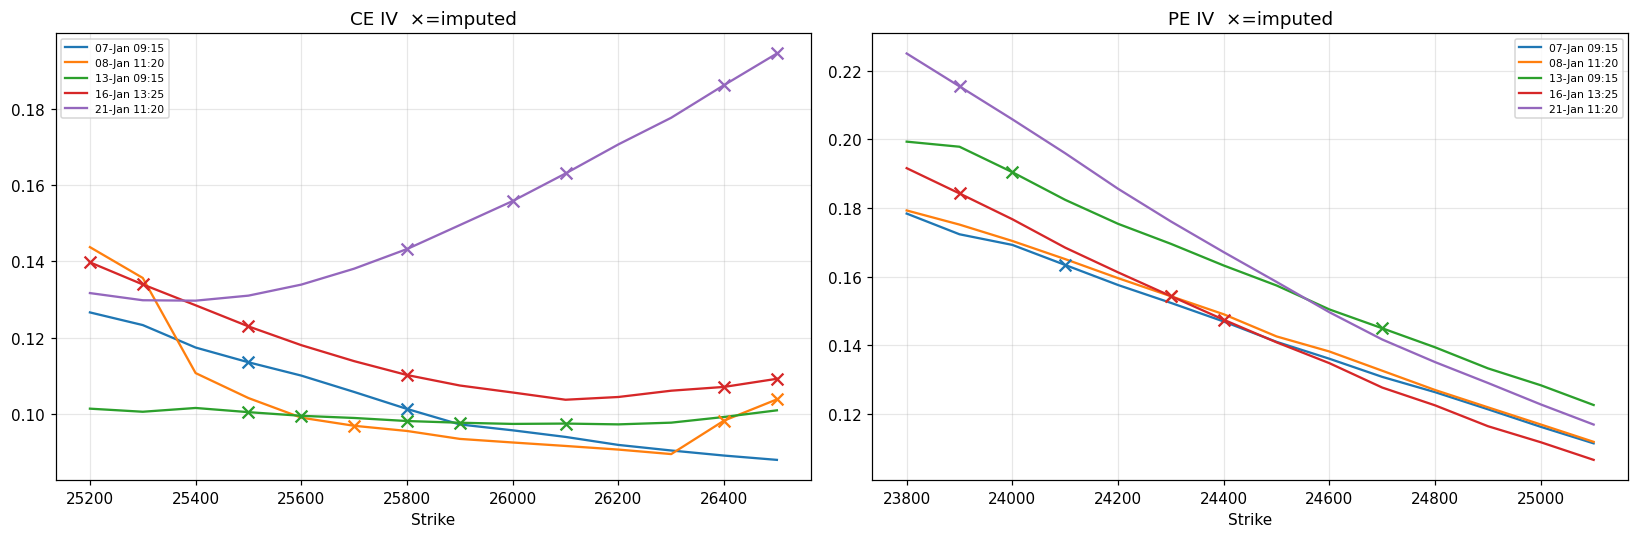

In [28]:
df_filled_plot = pd.read_csv(FILLED_PATH)
df_filled_plot['datetime'] = pd.to_datetime(df_filled_plot['datetime'], format='%d-%m-%Y %H:%M')
sample_times = df_filled_plot['datetime'].iloc[[0, 100, 300, 500, 700]]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ts in sample_times:
    row_raw  = df_raw[df_raw['datetime'] == ts].iloc[0]
    row_fill = df_filled_plot[df_filled_plot['datetime'] == ts].iloc[0]
    label    = ts.strftime('%d-%b %H:%M')
    axes[0].plot(ce_strikes, row_fill[ce_cols].values, lw=1.5, label=label)
    miss_ce = [i for i,c in enumerate(ce_cols) if pd.isna(row_raw[c])]
    axes[0].scatter([ce_strikes[i] for i in miss_ce], [row_fill[ce_cols[i]] for i in miss_ce], marker='x', s=60, zorder=5)
    axes[1].plot(pe_strikes, row_fill[pe_cols].values, lw=1.5, label=label)
    miss_pe = [i for i,c in enumerate(pe_cols) if pd.isna(row_raw[c])]
    axes[1].scatter([pe_strikes[i] for i in miss_pe], [row_fill[pe_cols[i]] for i in miss_pe], marker='x', s=60, zorder=5)
axes[0].set_title('CE IV  ×=imputed'); axes[0].set_xlabel('Strike')
axes[1].set_title('PE IV  ×=imputed'); axes[1].set_xlabel('Strike')
for ax in axes: ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Done — v4 Submission

**Method:** `W_TMP × temporal + W_SVD × SVD(rank=3) + W_V3 × [0.20×poly2 + 0.30×poly2_var + 0.20×PCHIP + 0.30×adaptive]`

Weights (`W_TMP`, `W_SVD`, `W_V3`) are CV-optimised in section 4.6.

Key upgrades from v3:
- **Temporal interpolation**: IV barely changes in 5 minutes, so bridging a 1–3 bar gap via linear time-axis interpolation is far more accurate than cross-sectional polynomial fitting
- **SVD rank-3 completion**: treats the full 975×14 CE and PE surface matrices simultaneously; rank 3 captures overall IV level, smile slope, and curvature with full temporal context